# Phase 0 — 실현 가능성 검증

이 노트북은 **분석 결과를 만들지 않는다.** 딱 하나를 판정한다:

> **이 영상으로 프로젝트를 진행할 가치가 있는가?**

영상을 2fps로 싸게 훑어 프레임별로 재는 것:

| 지표 | 왜 재는가 |
|---|---|
| 경기장 키포인트 수 | 화면→경기장 좌표 변환(호모그래피)이 가능한가. **여기가 실패하면 전부 실패한다** |
| 화면 내 선수 수 | 클로즈업·리플레이·관중샷을 걸러내는 가장 강력한 신호 |
| 카메라 이동 속도 | 컷 전환과 급속 팬 감지 |

그 결과 **분석 가능 구간(analyzable window)** 을 뽑고, 탈락 구간은 이유와 함께 남긴다.

**실행 순서:** 위에서부터 셀을 차례로 실행. 런타임은 `GPU` 로 바꿀 것 (런타임 → 런타임 유형 변경 → T4 GPU).


In [10]:
#@title 1. 환경 설치 (2~3분)
!pip install -q ultralytics gdown
!pip install -q git+https://github.com/roboflow/sports.git

# pip 이 조용히 실패하는 일이 있다. 실제로 import 되는지 여기서 확인한다.
import importlib

_missing = []
for _m in ("ultralytics", "supervision", "sports", "cv2", "numpy"):
    try:
        importlib.import_module(_m)
        print("  OK  ", _m)
    except ImportError as _e:
        _missing.append(_m)
        print("  FAIL", _m, "-", _e)

print()
if _missing:
    print("설치 실패:", ", ".join(_missing))
    print("→ 위 pip 출력에서 에러를 확인할 것")
    print("→ 충돌 경고가 있었다면: 런타임 > 세션 다시 시작 후 이 셀부터 재실행")
else:
    print("설치 완료 - 2번 셀로 진행")

  Preparing metadata (setup.py) ... done
  OK   ultralytics
  OK   supervision
  OK   sports
  OK   cv2
  OK   numpy

설치 완료 - 2번 셀로 진행


In [11]:
#@title 2. 파이프라인 코드 가져오기
import os, sys, shutil, subprocess, importlib

REPO_URL = "https://github.com/songsuhan04/football-vision.git"
REPO_DIR = "football-vision"
MARKER = os.path.join("notebook", "pipeline", "presets.py")   # 리포가 온전한지 판별


def _sh(*args):
    return subprocess.run(args, capture_output=True, text=True)


def _intact(root: str) -> bool:
    return os.path.isfile(os.path.join(root, MARKER))


if _intact(".."):
    ROOT = ".."                       # 이미 리포 안에서 실행 중
else:
    # 이전에 clone 이 실패해 껍데기만 남았을 수 있다. 온전하지 않으면 지우고 새로 받는다.
    if os.path.isdir(REPO_DIR) and not _intact(REPO_DIR):
        shutil.rmtree(REPO_DIR, ignore_errors=True)

    if os.path.isdir(REPO_DIR):
        _sh("git", "-C", REPO_DIR, "pull", "-q")
    else:
        token = ""                    # public 리포면 불필요
        try:
            from google.colab import userdata
            token = userdata.get("GITHUB_TOKEN") or ""
        except Exception:
            pass
        url = REPO_URL.replace("https://", f"https://{token}@") if token else REPO_URL
        r = _sh("git", "clone", "-q", url, REPO_DIR)
        if r.returncode or not _intact(REPO_DIR):
            shutil.rmtree(REPO_DIR, ignore_errors=True)
            raise RuntimeError(
                "리포를 받지 못했다. "
                "public 인지 확인: https://github.com/songsuhan04/football-vision / "
                "private 이면 Colab 좌측 열쇠 Secrets 에 GITHUB_TOKEN(repo scope) 추가. "
                f"git: {r.stderr.strip()[-300:]}")
    ROOT = REPO_DIR

NOTEBOOK_DIR = os.path.abspath(os.path.join(ROOT, "notebook"))
if NOTEBOOK_DIR not in sys.path:
    sys.path.insert(0, NOTEBOOK_DIR)

import pipeline
for _m in ("presets", "geometry", "models", "scan", "windows", "report"):
    importlib.reload(importlib.import_module(f"pipeline.{_m}"))
from pipeline import presets, geometry, models, scan, windows, report

print("ROOT      :", os.path.abspath(ROOT))
print("프리셋    :", list(presets.PRESETS))
# 1번 셀을 건너뛰면 5번(모델 로드)에서야 터진다. 여기서 미리 잡는다.
try:
    models.check_env()
    print()
    print("2번 셀 성공 - 3-A 로 진행할 것")
except ImportError as e:
    print()
    print("경고:", e)

ROOT      : /content/football-vision
프리셋    : ['broadcast', 'handheld_elevated']

2번 셀 성공 - 3-A 로 진행할 것


## 3. 영상 준비

**두 경로 중 하나를 고른다.**

### 3-A. 공개 샘플 클립 — *먼저 이걸로 돌릴 것*

DFL Bundesliga 중계 클립(Kaggle 공개 데이터). 저작권 걱정이 없고, 모델이 검증된 영상이다.

**여기서 실패하면 영상 문제가 아니라 코드 문제다.** 이 분리가 디버깅 시간을 크게 줄인다.

### 3-B. 내 영상

`3-B` 셀에서 업로드하거나 Google Drive를 마운트한다. 유튜브 URL도 받는다.

> ⚠️ 90분 풀경기는 스캔에만 오래 걸린다. 처음에는 `MAX_SECONDS` 로 5~10분만 잘라 확인할 것.

In [12]:
#@title 3-A. 공개 샘플 클립 (Phase 0-A)
!gdown -q -O "sample_broadcast.mp4" "https://drive.google.com/uc?id=1vVwjW1dE1drIdd4ZSILfbCGPD4weoNiu"

VIDEO_PATH = "sample_broadcast.mp4"
PRESET = presets.get("broadcast")
START_S = 0.0
MAX_SECONDS = None      # 전체 스캔. 빠른 확인은 60.0 등으로

import supervision as sv
_info = sv.VideoInfo.from_video_path(VIDEO_PATH)
print(f"{VIDEO_PATH}  {_info.width}x{_info.height}  {_info.fps}fps  "
      f"{_info.total_frames/_info.fps:.0f}초")

sample_broadcast.mp4  1920x1080  25.0fps  30초


In [ ]:
#@title 3-B. 내 영상 (3-A 대신 실행)
# --- 아래 셋 중 하나만 주석 해제 ---

## (1) 브라우저 업로드
# from google.colab import files
# up = files.upload()
# VIDEO_PATH = next(iter(up))

## (2) Google Drive
# from google.colab import drive
# drive.mount("/content/drive")
# VIDEO_PATH = "/content/drive/MyDrive/football/match.mp4"

## (3) 유튜브 (본인이 권리를 가진 영상만)
# !pip install -q yt-dlp
# URL = "https://www.youtube.com/watch?v=..."
# !yt-dlp -f "bv*[height<=1080][ext=mp4]+ba[ext=m4a]/b[height<=1080]" -o "match.mp4" "$URL"
# VIDEO_PATH = "match.mp4"

# --- 소스에 맞는 프리셋 ---
# PRESET = presets.get("broadcast")            # 프로 중계
# PRESET = presets.get("handheld_elevated")    # 스마트폰 높은 위치 pitch view
#     실측 규격을 알면 주입할 것 (기본 105x68m):
#     PRESET = PRESET.with_(pitch_length_cm=10000, pitch_width_cm=6400)

# START_S = 0.0
# MAX_SECONDS = 600.0    # 처음엔 10분만 훑어볼 것
pass

In [13]:
#@title 4. 모델 로드 (최초 1회 가중치 ~180MB 다운로드)
MODELS = models.load()          # weights/ 에 캐시된다. 두 번째부터는 즉시 로드

print()
print("device    :", MODELS.device)
print("클래스    :", MODELS.cls)
print("키포인트  :", MODELS.n_keypoints, "개")
print("프리셋    :", PRESET.name,
      f"| 경기장 {PRESET.pitch_length_cm/100:.0f}x{PRESET.pitch_width_cm/100:.0f}m")


device    : cuda
클래스    : {'ball': 0, 'goalkeeper': 1, 'player': 2, 'referee': 3}
키포인트  : 32 개
프리셋    : broadcast | 경기장 105x68m


## 5. 눈으로 먼저 확인

숫자를 보기 전에 프레임 하나를 눈으로 본다. 여기서 이상하면 스캔을 돌릴 이유가 없다.

- **왼쪽**: 원본에 선수 박스 + 경기장 키포인트
- **오른쪽**: 그 키포인트로 변환한 2D 탑다운

**판정 기준**: 2D 점들이 경기장 안에 있고, 실제 선수 배치와 비슷한 모양인가?

키포인트 통과 14개 · RANSAC 인라이어 11개 · 선수 23명
경기장 안으로 매핑된 선수: 23/23명


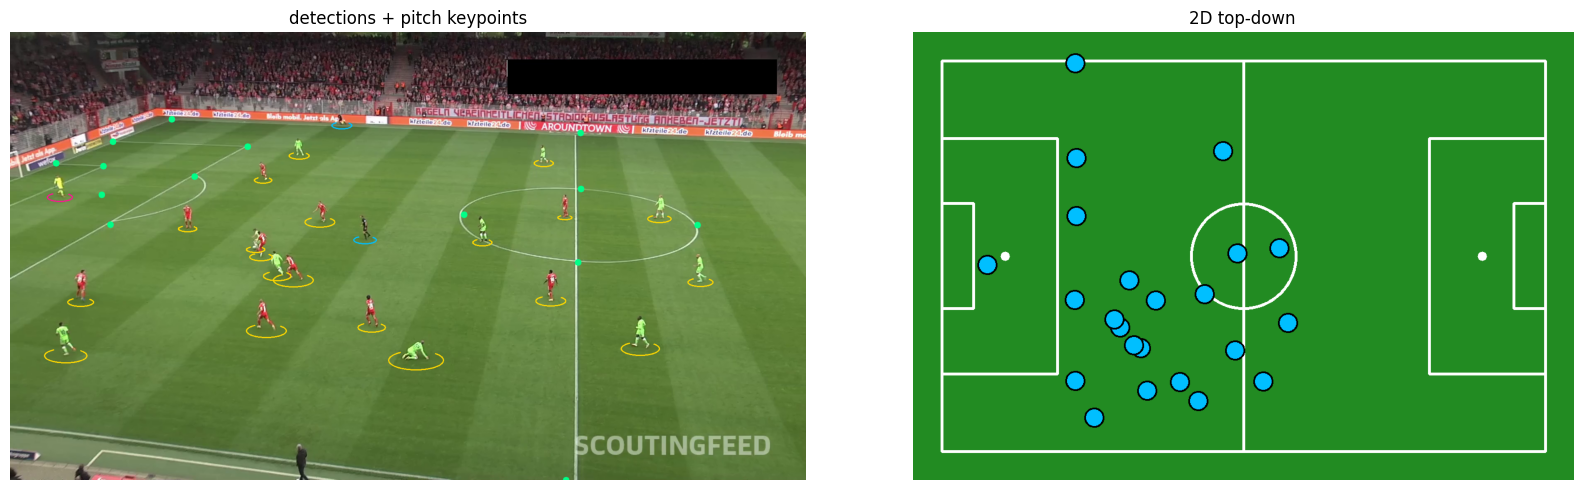

In [14]:
#@title 5. 단일 프레임 시각 확인
import numpy as np, supervision as sv, matplotlib.pyplot as plt
from sports.annotators.soccer import draw_pitch, draw_points_on_pitch

PROBE_T = 10.0   #@param {type:"number"}

_info = sv.VideoInfo.from_video_path(VIDEO_PATH)
frame = next(sv.get_video_frames_generator(
    VIDEO_PATH, start=int(PROBE_T * _info.fps)))

# --- 선수 탐지 ---
det = sv.Detections.from_ultralytics(
    MODELS.player(frame, conf=PRESET.det_conf,
                  imgsz=PRESET.det_imgsz, verbose=False)[0])
det = det[det.class_id != MODELS.id_of("ball")]
det = det.with_nms(threshold=PRESET.nms_threshold, class_agnostic=True)

# --- 경기장 키포인트 ---
kp = sv.KeyPoints.from_ultralytics(
    MODELS.field(frame, conf=PRESET.det_conf, verbose=False)[0])

# --- 원본 오버레이 ---
left = frame.copy()
left = sv.EllipseAnnotator(color=sv.ColorPalette.from_hex(
    ["#00BFFF", "#FF1493", "#FFD700"]), thickness=2).annotate(left, det)
kp_conf = geometry.kp_confidence(kp)
mask = kp_conf[0] > PRESET.kp_conf
left = sv.VertexAnnotator(color=sv.Color.from_hex("#00FF88"), radius=8).annotate(
    left, sv.KeyPoints(xy=kp.xy[0][mask][np.newaxis, ...]))

# --- 2D 변환 ---
config = models.pitch_config(PRESET)
vertices_cm = np.array(config.vertices, dtype=np.float32)
H, n_kp, n_in = geometry.solve_homography(
    kp.xy[0], kp_conf[0], vertices_cm, PRESET.kp_conf, PRESET.min_keypoints)

print(f"키포인트 통과 {n_kp}개 · RANSAC 인라이어 {n_in}개 · 선수 {len(det)}명")

fig, ax = plt.subplots(1, 2, figsize=(17, 5))
ax[0].imshow(left[..., ::-1]); ax[0].axis("off")
ax[0].set_title("detections + pitch keypoints")

probes = geometry.probe_points(_info.width, _info.height)
if H is None or not geometry.is_sane(H, probes):
    ax[1].text(0.5, 0.5, "homography FAILED", ha="center", va="center",
               color="#e74c3c", fontsize=14)
    ax[1].axis("off")
else:
    xy_px = det.get_anchors_coordinates(anchor=sv.Position.BOTTOM_CENTER)
    xy_m = geometry.to_pitch_m(H, xy_px)
    radar = draw_pitch(config=config)
    radar = draw_points_on_pitch(config=config, xy=xy_m * 100,   # draw_* 는 cm
                                 face_color=sv.Color.from_hex("#00BFFF"),
                                 edge_color=sv.Color.BLACK, radius=16, pitch=radar)
    ax[1].imshow(radar[..., ::-1]); ax[1].axis("off"); ax[1].set_title("2D top-down")
    L, W = PRESET.pitch_length_cm / 100, PRESET.pitch_width_cm / 100
    inside = ((xy_m[:, 0] >= 0) & (xy_m[:, 0] <= L) &
              (xy_m[:, 1] >= 0) & (xy_m[:, 1] <= W))
    print(f"경기장 안으로 매핑된 선수: {inside.sum()}/{len(xy_m)}명")
plt.tight_layout(); plt.show()

## 6. 사전 스캔

영상 전체를 2fps로 훑는다. 90분 영상이면 약 10,800프레임 × 모델 2개.
T4 기준 대략 **10분 영상당 1~2분** 정도 걸린다.

In [15]:
#@title 6. 스캔 실행
SCAN = scan.scan(VIDEO_PATH, MODELS, PRESET,
                 start_s=START_S, max_seconds=MAX_SECONDS)
print(f"\n스캔 완료: {len(SCAN['rows'])}프레임")

scan @2.0fps:   0%|          | 0/62 [00:00<?, ?it/s]


스캔 완료: 63프레임


In [16]:
#@title 7. 판정
WIN = windows.find_windows(SCAN, PRESET)
report.print_summary(SCAN, WIN, PRESET)

  Phase 0 진단  |  프리셋: broadcast
  영상      1920x1080  25.0fps  30초
  스캔      63프레임 / 30초 (@2.0fps)

  ── 프레임 품질 ────────────────────────────────────────────
  키포인트 4개 이상   ████████████████████████ 100.0%
  호모그래피 성립     ████████████████████████ 100.0%
  화면 내 평균 선수   20.0명  (필터 기준 6명)

  ── 분석 가능 구간 ─────────────────────────────────────────
  채택 1개 / 탈락 0개
  분석 가능 시간      ████████████████████████ 30초 (100.0%)

  ✅  w01      0.0~   30.2s ( 30.2s)  kp 12.5 · 선수 20.0명

  ✅ GO — 짧은 클립 검증 통과 — 커버리지 100%, 키포인트율 100%
--------------------------------------------------------------
  파이프라인이 정상 동작한다.
  → 이제 실제 경기 영상(길이 5분 이상)으로 채택 구간 수를 측정할 것.


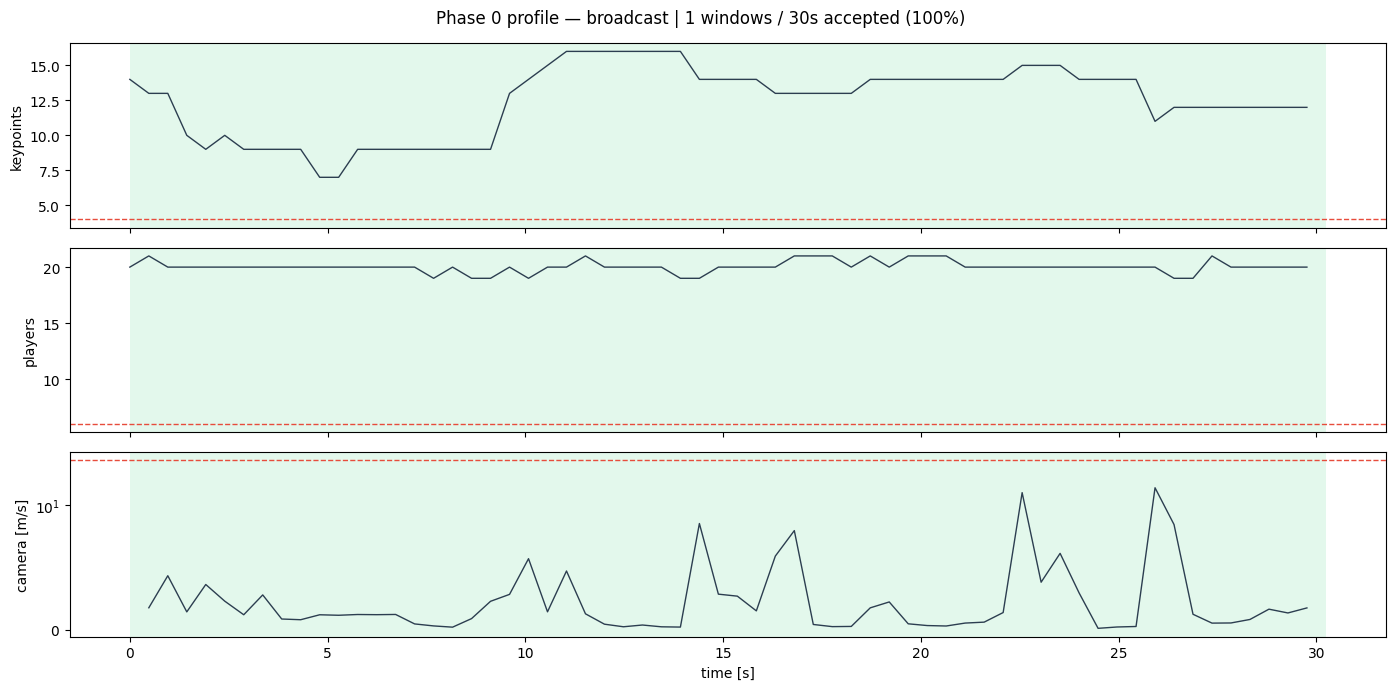

In [17]:
#@title 8. 시간축 프로파일
import matplotlib.pyplot as plt
fig = report.plot_profile(SCAN, WIN, PRESET)
plt.show()

In [ ]:
#@title 9. 결과 저장 + 다운로드
import json, os

out = {"scan": SCAN, "windows": WIN}
name = f"phase0_{PRESET.name}_{os.path.basename(VIDEO_PATH).rsplit('.',1)[0]}.json"
with open(name, "w", encoding="utf-8") as f:
    json.dump(out, f, ensure_ascii=False)
print(f"{name}  ({os.path.getsize(name)/1e6:.1f} MB)")

try:
    from google.colab import files
    files.download(name)
except Exception:
    pass

## 다음 단계

판정 결과에 따라 갈린다.

| 판정 | 다음 행동 |
|---|---|
| **✅ GO** | Phase 1 — 채택 구간별 정밀 처리(10fps) + `analysis-bundle.json` 생성 |
| **⚠️ WARN** (구간 부족) | `PRESET.with_(min_window_s=6.0, min_players=5)` 로 완화 후 8번 셀 재실행. 그래도 적으면 더 긴 영상으로 |
| **⚠️ WARN** (키포인트율 낮음) | Phase 0.5 — 광학 흐름 H 전파 구현 |
| **🛑 STOP** (중계인데 키포인트율 낮음) | 4-A 샘플 클립으로 돌아가 코드 검증 |
| **🛑 STOP** (화각 부족) | (a) 넓은 구간만 채택 (b) 키포인트 모델 파인튜닝 (c) 재촬영 — 결정 필요 |

**필터만 바꿔 재판정하려면** 6번(스캔)을 다시 돌릴 필요 없이 7번부터 실행하면 된다:

```python
PRESET = PRESET.with_(min_window_s=6.0, min_players=5)
WIN = windows.find_windows(SCAN, PRESET)
report.print_summary(SCAN, WIN, PRESET)
```

전체 설계는 [`docs/PLAN.md`](../docs/PLAN.md) 참고.

In [19]:
!pip install -q -U yt-dlp

URL = "https://youtu.be/TySF_ZpWr70"
!yt-dlp --extractor-args "youtube:player_client=android_vr" \
        -f "bv*[height<=1080][ext=mp4]/b[height<=1080]" \
        --retries 10 --fragment-retries 10 \
        -o "match.mp4" "$URL"

VIDEO_PATH  = "match.mp4"
PRESET      = presets.get("broadcast")
START_S     = 0.0
MAX_SECONDS = None       # 하이라이트는 짧으니 전체

import supervision as sv, os
_i = sv.VideoInfo.from_video_path(VIDEO_PATH)
print(f"{_i.width}x{_i.height} {_i.fps}fps {_i.total_frames/_i.fps/60:.1f}분")

[youtube] Extracting URL: https://youtu.be/TySF_ZpWr70
[youtube] TySF_ZpWr70: Downloading webpage
[youtube] TySF_ZpWr70: Downloading android vr player API JSON
ERROR: [youtube] TySF_ZpWr70: Sign in to confirm you’re not a bot. Use --cookies-from-browser or --cookies for the authentication. See  https://github.com/yt-dlp/yt-dlp/wiki/FAQ#how-do-i-pass-cookies-to-yt-dlp  for how to manually pass cookies. Also see  https://github.com/yt-dlp/yt-dlp/wiki/Extractors#exporting-youtube-cookies  for tips on effectively exporting YouTube cookies


Exception: Could not open video at match.mp4